In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [2]:
pipeline = joblib.load(
    "../models/xgboost_prediction_pipeline.pkl"
)

model = pipeline["model"]
features = pipeline["features"]

print("Model loaded successfully!")
print("Number of features:", len(features))

Model loaded successfully!
Number of features: 34


In [3]:
feature_importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(10)

,Feature,Importance
27,d_1906,0.201447
33,d_1912,0.175773
13,d_1892,0.120835
11,d_1890,0.048126
29,d_1908,0.033906
19,d_1898,0.030581
20,d_1899,0.028007
28,d_1907,0.027701
30,d_1909,0.025301
31,d_1910,0.023352


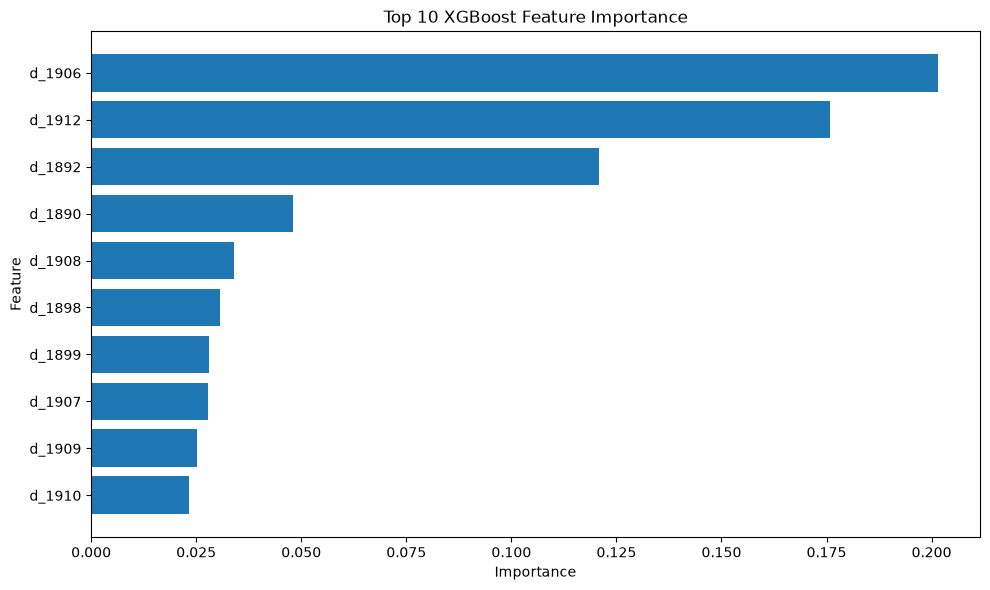

In [4]:
top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [5]:
feature_importance_df.to_csv(
    "../data/processed/xgboost_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [6]:
feature_importance_check = pd.read_csv(
    "../data/processed/xgboost_feature_importance.csv"
)

feature_importance_check.head(10)

,Feature,Importance
0,d_1906,0.201447
1,d_1912,0.175773
2,d_1892,0.120835
3,d_1890,0.048126
4,d_1908,0.033906
5,d_1898,0.030581
6,d_1899,0.028007
7,d_1907,0.027701
8,d_1909,0.025301
9,d_1910,0.023352


In [7]:
top_10_features = feature_importance_check.head(10)

top_10_features

,Feature,Importance
0,d_1906,0.201447
1,d_1912,0.175773
2,d_1892,0.120835
3,d_1890,0.048126
4,d_1908,0.033906
5,d_1898,0.030581
6,d_1899,0.028007
7,d_1907,0.027701
8,d_1909,0.025301
9,d_1910,0.023352


In [8]:
print("Explainable AI Summary")
print("-" * 30)

top_feature = top_10_features.iloc[0]

print(
    f"The most important feature is {top_feature['Feature']} "
    f"with an importance score of {top_feature['Importance']:.4f}."
)

print(
    "The feature importance values show which input features "
    "contribute most to the XGBoost model's predictions."
)

Explainable AI Summary
------------------------------
The most important feature is d_1906 with an importance score of 0.2014.
The feature importance values show which input features contribute most to the XGBoost model's predictions.


In [9]:
print("Phase 7 - Explainable AI completed successfully!")
print("Model: XGBoost")
print("Total Features:", len(features))
print("Top Feature:", top_10_features.iloc[0]["Feature"])
print("Top Feature Importance:", round(top_10_features.iloc[0]["Importance"], 4))

Phase 7 - Explainable AI completed successfully!
Model: XGBoost
Total Features: 34
Top Feature: d_1906
Top Feature Importance: 0.2014


In [2]:
print("X_train" in globals())
print("gb_model" in globals())

False
False


In [3]:
print("final_ml_df" in globals())

False


In [4]:
import os

files = os.listdir()

for file in files:
    print(file)

01_Data_Loading.ipynb
02_Data_Cleaning.ipynb
03_Feature_Engineering.ipynb
04_Exploratory_Data_Analysis.ipynb
05.Inventory optimization.ipynb
06_Explainable_AI.ipynb
app.py
catboost_info
final_ml_dataset.csv
gradient_boosting_demand_model.pkl
label_encoders.pkl
Machine learning and modelling.ipynb
model_features.pkl


In [5]:
import pandas as pd
import joblib

# Load final ML dataset
final_ml_df = pd.read_csv("final_ml_dataset.csv")

print("Final ML dataset shape:", final_ml_df.shape)
print(final_ml_df.head())

Final ML dataset shape: (30490, 22)
         item_id    dept_id   cat_id store_id state_id  lag_1  lag_7  lag_28  \
0  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1       CA      1      0       1   
1  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1       CA      0      0       1   
2  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1       CA      1      2       0   
3  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1       CA      7      5       6   
4  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1       CA      2      1       0   

   rolling_mean_7  rolling_mean_28  ...  wm_yr_wk weekday  wday month  year  \
0        1.000000         0.964286  ...     11613  Sunday     2     4  2016   
1        0.142857         0.107143  ...     11613  Sunday     2     4  2016   
2        1.000000         0.535714  ...     11613  Sunday     2     4  2016   
3        3.000000         1.964286  ...     11613  Sunday     2     4  2016   
4        1.285714         1.214286  ...     11613  Sunday     2     4  2016   

   event

In [6]:
gb_model = joblib.load("gradient_boosting_demand_model.pkl")

print("Gradient Boosting model loaded successfully!")

Gradient Boosting model loaded successfully!


In [7]:
model_features = joblib.load("model_features.pkl")

print("Number of model features:", len(model_features))
print(model_features)

Number of model features: 20
['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'lag_1', 'lag_7', 'lag_28', 'rolling_mean_7', 'rolling_mean_28', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap']


In [8]:
label_encoders = joblib.load("label_encoders.pkl")

print("Label encoders loaded successfully!")

Label encoders loaded successfully!


In [9]:
X = final_ml_df.drop(columns=["d_1913", "date"]).copy()

for col, encoder in label_encoders.items():
    if col in X.columns:
        X[col] = encoder.transform(X[col])

X = X[model_features]

print("X shape:", X.shape)
print(X.head())

X shape: (30490, 20)
   item_id  dept_id  cat_id  store_id  state_id  lag_1  lag_7  lag_28  \
0     1437        3       1         0         0      1      0       1   
1     1438        3       1         0         0      0      0       1   
2     1439        3       1         0         0      1      2       0   
3     1440        3       1         0         0      7      5       6   
4     1441        3       1         0         0      2      1       0   

   rolling_mean_7  rolling_mean_28  wm_yr_wk  weekday  wday  month  year  \
0        1.000000         0.964286     11613        0     2      4  2016   
1        0.142857         0.107143     11613        0     2      4  2016   
2        1.000000         0.535714     11613        0     2      4  2016   
3        3.000000         1.964286     11613        0     2      4  2016   
4        1.285714         1.214286     11613        0     2      4  2016   

   event_name_1  event_type_1  event_name_2  event_type_2  snap  
0             0  

In [10]:
xai_importance = pd.DataFrame({
    "Feature": model_features,
    "Importance": gb_model.feature_importances_
})

xai_importance = xai_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 10 Features Influencing Demand Prediction")
print("==============================================")
print(xai_importance.head(10))

Top 10 Features Influencing Demand Prediction
           Feature  Importance
0   rolling_mean_7    0.535569
1  rolling_mean_28    0.285078
2            lag_7    0.060906
3           lag_28    0.059625
4            lag_1    0.049273
5          item_id    0.005171
6         store_id    0.003770
7         state_id    0.000504
8          dept_id    0.000105
9           cat_id    0.000000


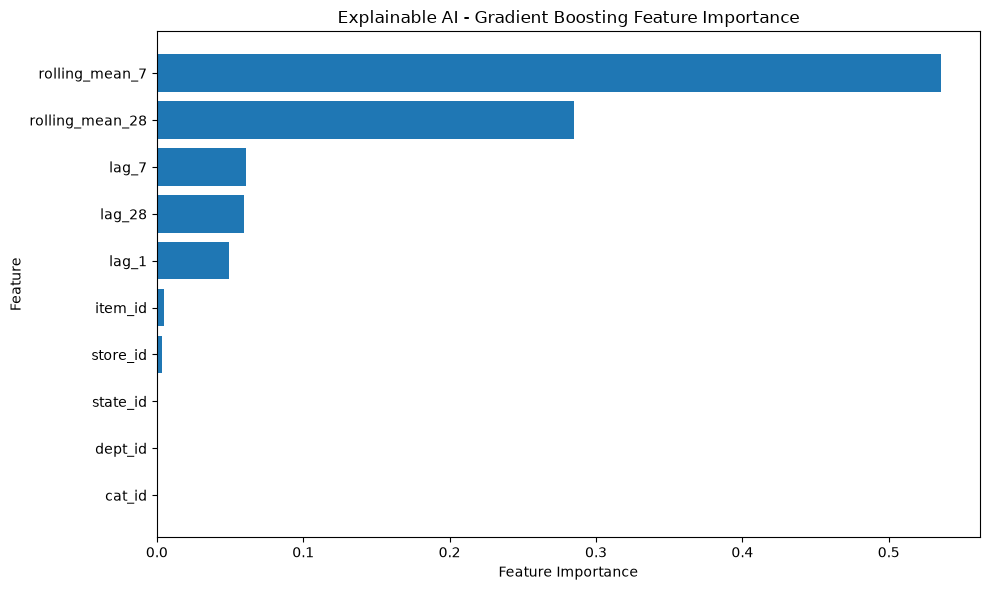

In [11]:
import matplotlib.pyplot as plt

top_xai = xai_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_xai["Feature"][::-1],
    top_xai["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Explainable AI - Gradient Boosting Feature Importance")

plt.tight_layout()
plt.show()

In [13]:
xai_importance.to_csv(
    "gradient_boosting_feature_importance.csv",
    index=False
)

print("Gradient Boosting XAI file saved successfully!")

Gradient Boosting XAI file saved successfully!


In [12]:
print("XAI Interpretation")
print("==================")

print(
    "The Gradient Boosting model relies primarily on historical demand "
    "features. The 7-day rolling mean is the most important feature, "
    "followed by the 28-day rolling mean."
)

print(
    "This indicates that recent weekly and longer-term demand patterns "
    "have the strongest influence on demand prediction."
)

XAI Interpretation
The Gradient Boosting model relies primarily on historical demand features. The 7-day rolling mean is the most important feature, followed by the 28-day rolling mean.
This indicates that recent weekly and longer-term demand patterns have the strongest influence on demand prediction.
